# BioTemporal-HAR — Full WISDM Pipeline

Complete implementation of the BioTemporal-HAR proposal on the full WISDM Smartphone and Smartwatch Activity and Biometrics dataset.

**Targets (from proposal §8)**
1. Activity recognition ≥ 95% accuracy (18 classes, subject-held-out splits)
2. Closed-set identity classification ≥ 90% top-1 accuracy (51 subjects)
3. Identity verification FAR < 1% with calibrated SDT thresholds
4. Multi-sensor fusion ablation: phone-only vs watch-only vs fused

**Data**: 51 subjects, 18 activities, phone & watch accelerometer + gyroscope at 20 Hz (~884 MB raw)

## 1. Setup

In [4]:
from __future__ import annotations

import json
import math
import os
import pickle
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import norm
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

# ┌─────────────────────────────────────────────────────────────────┐
# │  RUN_MODE: change this one line to switch between modes         │
# │  "fast"  → ~5 min total  (smoke-test, low accuracy expected)   │
# │  "full"  → ~2-3h CPU / ~20-40 min GPU  (target ≥ 95% acc)     │
# └─────────────────────────────────────────────────────────────────┘
RUN_MODE = "full"   # ← change to "full" for the real run

CONFIGS = {
    "fast": dict(
        epochs=5, batch_size=256, lr=3e-4, weight_decay=1e-4, warmup=2,
        conv_dims=[16, 32], lstm_hidden=32, lstm_layers=1, dropout=0.2,
        ablation_epochs=3,
    ),
    "full": dict(
        epochs=60, batch_size=256, lr=3e-4, weight_decay=1e-4, warmup=5,
        conv_dims=[64, 128, 256], lstm_hidden=128, lstm_layers=2, dropout=0.35,
        ablation_epochs=30,
    ),
}
cfg = CONFIGS[RUN_MODE]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path("__file__").resolve().parent.parent
if not (PROJECT_ROOT / "WISDM_dataset").exists():
    PROJECT_ROOT = Path.cwd()
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "WISDM_dataset").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

RAW_ROOT = (
    PROJECT_ROOT
    / "data"
    / "wisdm-dataset"
    / "raw"
)

PROJECT_ROOT = Path(r"C:\Users\Louis\Documents\GitHub\BioTemporal-HAR")
RAW_ROOT = PROJECT_ROOT / "data" / "wisdm-dataset" / "raw"

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
CACHE_DIR    = PROJECT_ROOT / "artifacts" / "cache"
ARTIFACT_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
assert RAW_ROOT.exists(), f"Raw data not found at {RAW_ROOT}"

ACTIVITY_MAP = {
    "A": "walking",   "B": "jogging",   "C": "stairs",
    "D": "sitting",   "E": "standing",  "F": "typing",
    "G": "teeth",     "H": "soup",      "I": "chips",
    "J": "pasta",     "K": "drinking",  "L": "sandwich",
    "M": "kicking",   "O": "catch",     "P": "dribbling",
    "Q": "writing",   "R": "clapping",  "S": "folding",
}
ACTIVITIES = sorted(ACTIVITY_MAP.keys())
SUBJECTS   = list(range(1600, 1651))
STREAMS    = ["phone_accel", "phone_gyro", "watch_accel", "watch_gyro"]
STREAM_DIRS = {
    "phone_accel": RAW_ROOT / "phone" / "accel",
    "phone_gyro":  RAW_ROOT / "phone" / "gyro",
    "watch_accel": RAW_ROOT / "watch" / "accel",
    "watch_gyro":  RAW_ROOT / "watch" / "gyro",
}

FS          = 20
WINDOW_SEC  = 10.0
STRIDE_SEC  = 2.5
WINDOW_SIZE = int(WINDOW_SEC * FS)
STRIDE      = int(STRIDE_SEC * FS)

rng = np.random.default_rng(SEED)
shuffled = rng.permutation(SUBJECTS).tolist()
N_TEST, N_VAL  = 8, 5
TEST_SUBJECTS  = sorted(shuffled[:N_TEST])
VAL_SUBJECTS   = sorted(shuffled[N_TEST:N_TEST + N_VAL])
TRAIN_SUBJECTS = sorted(shuffled[N_TEST + N_VAL:])

EPOCHS           = cfg["epochs"]
BATCH_SIZE       = cfg["batch_size"]
LR               = cfg["lr"]
WEIGHT_DECAY     = cfg["weight_decay"]
LR_WARMUP_EPOCHS = cfg["warmup"]
TARGET_FAR       = 0.01
ACTIVITY_LOSS_W  = 1.0
IDENTITY_LOSS_W  = 0.4
MODEL_CONV_DIMS  = cfg["conv_dims"]
MODEL_LSTM_H     = cfg["lstm_hidden"]
MODEL_LSTM_L     = cfg["lstm_layers"]
MODEL_DROPOUT    = cfg["dropout"]
ABLATION_EPOCHS  = cfg["ablation_epochs"]

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_CUDA = DEVICE.type == "cuda"
if USE_CUDA:
    torch.backends.cudnn.benchmark = True   # auto-tune Conv kernels for fixed input size
    BATCH_SIZE *= 2                          # GPU has more memory — larger batches are faster

print(f"┌── RUN_MODE = '{RUN_MODE}' {'─'*40}")
print(f"│  epochs={EPOCHS}  conv={MODEL_CONV_DIMS}  lstm={MODEL_LSTM_H}×{MODEL_LSTM_L}  ablation={ABLATION_EPOCHS}")
print(f"│  batch_size={BATCH_SIZE}  PyTorch={torch.__version__}")
print(f"│  device={DEVICE}", end="")
if USE_CUDA:
    props = torch.cuda.get_device_properties(0)
    print(f"  [{props.name}, {props.total_memory // 1024**3} GB VRAM]  AMP enabled")
else:
    print("  (CPU — set RUN_MODE='fast' for a quick smoke-test)")
print(f"│  Train={len(TRAIN_SUBJECTS)} subjects | Val={len(VAL_SUBJECTS)} | Test={len(TEST_SUBJECTS)}")
print(f"└{'─'*54}")

Project root : C:\Users\Louis\Documents\GitHub\BioTemporal-HAR
┌── RUN_MODE = 'full' ────────────────────────────────────────
│  epochs=60  conv=[64, 128, 256]  lstm=128×2  ablation=30
│  batch_size=256  PyTorch=2.9.0+cpu
│  device=cpu  (CPU — set RUN_MODE='fast' for a quick smoke-test)
│  Train=38 subjects | Val=5 | Test=8
└──────────────────────────────────────────────────────


## 2. Load & Cache Raw Data

Each raw file has rows `subject_id,activity,timestamp,x,y,z;`. We load all four streams for all 51 subjects and cache a fused NumPy array to disk so subsequent runs skip the 884 MB parse.

In [5]:
import io
from concurrent.futures import ThreadPoolExecutor

def parse_stream_file_fast(path: Path) -> pd.DataFrame:
    text = path.read_text(errors="ignore").replace(";", "")
    return pd.read_csv(
        io.StringIO(text), sep=",", header=None,
        names=["subject", "activity", "timestamp", "x", "y", "z"],
        dtype={"subject": "int32", "activity": "str",
               "timestamp": "int64", "x": "float32", "y": "float32", "z": "float32"},
        on_bad_lines="skip",
    ).dropna()


def load_stream_parallel(stream_name: str) -> pd.DataFrame:
    device, sensor = stream_name.split("_")
    folder = STREAM_DIRS[stream_name]
    def load_one(subj):
        p = folder / f"data_{subj}_{sensor}_{device}.txt"
        return parse_stream_file_fast(p) if p.exists() else None
    with ThreadPoolExecutor(max_workers=8) as ex:
        results = list(ex.map(load_one, SUBJECTS))
    return pd.concat([r for r in results if r is not None], ignore_index=True)


CACHE_FILE = CACHE_DIR / f"fused_W{WINDOW_SIZE}_S{STRIDE}.npz"

if CACHE_FILE.exists():
    print("Loading cached windows …")
    cache = np.load(CACHE_FILE, allow_pickle=True)
    X_train      = cache["X_train"]
    y_act_train  = cache["y_act_train"]
    y_sub_train  = cache["y_sub_train"]
    X_val        = cache["X_val"]
    y_act_val    = cache["y_act_val"]
    y_sub_val    = cache["y_sub_val"]
    X_test       = cache["X_test"]
    y_act_test   = cache["y_act_test"]
    y_sub_test   = cache["y_sub_test"]
    act_encoder  = pickle.loads(bytes(cache["act_encoder"]))
    sub_encoder  = pickle.loads(bytes(cache["sub_encoder"]))
    print(f"  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
else:
    print("Parsing raw files (pandas C parser + parallel threads) …")
    t0 = time.time()

    # 1. Load streams
    stream_data: dict[str, pd.DataFrame] = {}
    for s in STREAMS:
        print(f"  {s} …", end=" ", flush=True)
        stream_data[s] = load_stream_parallel(s)
        print(f"{len(stream_data[s]):,} rows  ({time.time()-t0:.1f}s)")

    # 2. Pre-group by (subject, activity) → O(1) lookup instead of O(N) filter per pair
    print("Grouping …", end=" ", flush=True)
    stream_groups: dict[str, dict] = {}
    for s in STREAMS:
        g = {}
        for (subj, act), grp in stream_data[s].groupby(["subject", "activity"], sort=False):
            g[(int(subj), str(act))] = (
                grp.sort_values("timestamp")[["x", "y", "z"]].to_numpy(dtype=np.float32)
            )
        stream_groups[s] = g
    del stream_data
    print(f"done  ({time.time()-t0:.1f}s)")

    # 3. Build fused windows
    print("Windowing …", end=" ", flush=True)
    all_windows, all_act, all_sub = [], [], []
    for subj in SUBJECTS:
        for act in ACTIVITIES:
            blocks = [stream_groups[s].get((subj, act)) for s in STREAMS]
            if any(b is None for b in blocks):
                continue
            min_len = min(len(b) for b in blocks)
            if min_len < WINDOW_SIZE:
                continue
            fused = np.concatenate([b[:min_len] for b in blocks], axis=1)  # (T, 12)
            for start in range(0, min_len - WINDOW_SIZE + 1, STRIDE):
                all_windows.append(fused[start : start + WINDOW_SIZE])
                all_act.append(act)
                all_sub.append(subj)

    X_all     = np.stack(all_windows).astype(np.float32)
    y_act_all = np.array(all_act)
    y_sub_all = np.array(all_sub, dtype=np.int32)
    del all_windows
    print(f"{len(X_all):,} windows {X_all.shape}  ({time.time()-t0:.1f}s)")

    # 4. Encode
    act_encoder = LabelEncoder().fit(y_act_all)
    sub_encoder = LabelEncoder().fit(y_sub_all)
    y_act_enc   = act_encoder.transform(y_act_all).astype(np.int64)
    y_sub_enc   = sub_encoder.transform(y_sub_all).astype(np.int64)

    # 5. Subject-held-out split
    tr_m = np.isin(y_sub_all, TRAIN_SUBJECTS)
    va_m = np.isin(y_sub_all, VAL_SUBJECTS)
    te_m = np.isin(y_sub_all, TEST_SUBJECTS)
    X_train,     X_val,     X_test     = X_all[tr_m],       X_all[va_m],       X_all[te_m]
    y_act_train, y_act_val, y_act_test = y_act_enc[tr_m], y_act_enc[va_m], y_act_enc[te_m]
    y_sub_train, y_sub_val, y_sub_test = y_sub_enc[tr_m], y_sub_enc[va_m], y_sub_enc[te_m]
    print(f"  Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}")
    print(f"  Total: {time.time()-t0:.1f}s")

    # 6. Cache
    np.savez_compressed(
        CACHE_FILE,
        X_train=X_train, y_act_train=y_act_train, y_sub_train=y_sub_train,
        X_val=X_val,     y_act_val=y_act_val,     y_sub_val=y_sub_val,
        X_test=X_test,   y_act_test=y_act_test,   y_sub_test=y_sub_test,
        act_encoder=np.frombuffer(pickle.dumps(act_encoder), dtype=np.uint8),
        sub_encoder=np.frombuffer(pickle.dumps(sub_encoder), dtype=np.uint8),
    )
    print(f"Cached → {CACHE_FILE.name}")

N_ACT = len(act_encoder.classes_)
N_SUB = len(sub_encoder.classes_)
N_CH  = X_train.shape[2]
print(f"\nActivities: {N_ACT} | Subjects: {N_SUB} | Channels: {N_CH} | Window: {WINDOW_SIZE}")
print("Labels:", [ACTIVITY_MAP[c] for c in act_encoder.classes_])


Parsing raw files (pandas C parser + parallel threads) …
  phone_accel … 4,804,403 rows  (3.3s)
  phone_gyro … 3,608,635 rows  (5.8s)
  watch_accel … 3,777,046 rows  (8.2s)
  watch_gyro … 3,440,342 rows  (10.6s)
Grouping … done  (15.5s)
Windowing … 62,964 windows (62964, 200, 12)  (16.2s)
  Train (45946, 200, 12) | Val (7333, 200, 12) | Test (9685, 200, 12)
  Total: 16.3s
Cached → fused_W200_S50.npz

Activities: 18 | Subjects: 51 | Channels: 12 | Window: 200
Labels: ['walking', 'jogging', 'stairs', 'sitting', 'standing', 'typing', 'teeth', 'soup', 'chips', 'pasta', 'drinking', 'sandwich', 'kicking', 'catch', 'dribbling', 'writing', 'clapping', 'folding']


## 3. Normalise

StandardScaler fitted on training windows only, applied channel-wise.

In [6]:
scaler = StandardScaler()
# Fit on flattened (N_train × T, C) then reshape back
scaler.fit(X_train.reshape(-1, N_CH))

def scale(X):
    sh = X.shape
    return scaler.transform(X.reshape(-1, sh[-1])).reshape(sh).astype(np.float32)

X_train_sc = scale(X_train)
X_val_sc   = scale(X_val)
X_test_sc  = scale(X_test)

print("Train mean ≈", X_train_sc.reshape(-1, N_CH).mean(axis=0).round(3))
print("Train std  ≈", X_train_sc.reshape(-1, N_CH).std(axis=0).round(3))

Train mean ≈ [-0. -0.  0.  0. -0. -0. -0.  0.  0.  0. -0. -0.]
Train std  ≈ [0.994 0.99  0.993 0.996 0.996 0.996 0.994 0.994 0.992 0.993 0.994 0.994]


## 4. Classical Feature-Based Baseline

Time-domain and frequency-domain features with mutual-information selection and a balanced random-forest classifier. Provides a leakage-safe lower bound to compare against CNN-LSTM.

In [7]:
def extract_features(X: np.ndarray) -> np.ndarray:
    """Extract handcrafted features from (N, T, C) windows → (N, F)."""
    N, T, C = X.shape
    feats = []

    # Time-domain per channel
    feats.append(X.mean(axis=1))                           # mean
    feats.append(X.std(axis=1))                            # std
    feats.append(np.abs(X).mean(axis=1))                   # mean abs
    feats.append(X.max(axis=1) - X.min(axis=1))            # range
    feats.append((X ** 2).mean(axis=1))                    # energy
    feats.append(np.median(X, axis=1))                     # median
    feats.append(np.percentile(X, 25, axis=1))             # Q1
    feats.append(np.percentile(X, 75, axis=1))             # Q3

    # Magnitude across channels within each sensor group (groups of 3)
    for g in range(C // 3):
        mag = np.linalg.norm(X[:, :, g*3:(g+1)*3], axis=2)  # (N, T)
        feats.append(mag.mean(axis=1, keepdims=True))
        feats.append(mag.std(axis=1, keepdims=True))
        feats.append((mag ** 2).mean(axis=1, keepdims=True))

    # Frequency domain: FFT magnitude mean/max for each channel
    fft_mag = np.abs(np.fft.rfft(X, axis=1))[:, 1:, :]  # drop DC
    feats.append(fft_mag.mean(axis=1))
    feats.append(fft_mag.max(axis=1))
    feats.append(np.argmax(fft_mag, axis=1).astype(np.float32))  # dominant freq bin

    return np.concatenate([f if f.ndim == 2 else f for f in feats], axis=1)


print("Extracting features …")
Xf_train = extract_features(X_train_sc)
Xf_val   = extract_features(X_val_sc)
Xf_test  = extract_features(X_test_sc)
print(f"Feature matrix shape: {Xf_train.shape}")

# Mutual-information feature selection
mi = mutual_info_classif(Xf_train, y_act_train, random_state=SEED)
top_k = min(64, Xf_train.shape[1])
top_idx = np.argsort(mi)[::-1][:top_k]
print(f"Selecting top-{top_k} features by MI")

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=SEED,
    min_samples_leaf=2,
)
rf.fit(Xf_train[:, top_idx], y_act_train)

rf_val_pred  = rf.predict(Xf_val[:, top_idx])
rf_test_pred = rf.predict(Xf_test[:, top_idx])

baseline_results = {
    "val_accuracy":  accuracy_score(y_act_val,  rf_val_pred),
    "val_macro_f1":  f1_score(y_act_val,  rf_val_pred, average="macro"),
    "test_accuracy": accuracy_score(y_act_test, rf_test_pred),
    "test_macro_f1": f1_score(y_act_test, rf_test_pred, average="macro"),
}
print("Random-Forest baseline:")
display(pd.DataFrame([baseline_results]).round(4))

Extracting features …
Feature matrix shape: (45946, 144)
Selecting top-64 features by MI
Random-Forest baseline:


,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1
0,0.6727,0.6716,0.6816,0.6743


## 5. BioTemporal-HAR Model

Compact multi-task CNN-LSTM with:
- **Residual Conv blocks** for local temporal feature extraction
- **Bidirectional LSTM** for sequential modeling
- **Self-attention pooling** to weight informative timesteps
- **Two heads**: activity classification (18 classes) + identity classification (51 subjects)

Multi-task training lets the shared encoder learn motion features useful for both tasks simultaneously.

In [8]:
class ResConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel: int = 3, dropout: float = 0.1):
        super().__init__()
        pad = kernel // 2
        self.body = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = nn.Conv1d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.act  = nn.GELU()

    def forward(self, x):
        return self.act(self.body(x) + self.skip(x))


class AttentionPool(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.score = nn.Linear(d_model, 1)

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        return (w * x).sum(dim=1)


class BioTemporalHAR(nn.Module):
    def __init__(
        self,
        n_channels: int = 12,
        n_act: int = 18,
        n_sub: int = 51,
        conv_dims: list[int] | None = None,
        lstm_hidden: int = 64,
        lstm_layers: int = 1,
        dropout: float = 0.3,
    ):
        super().__init__()
        if conv_dims is None:
            conv_dims = [32, 64, 128]

        layers: list[nn.Module] = []
        in_ch = n_channels
        for i, out_ch in enumerate(conv_dims):
            layers.append(ResConvBlock(in_ch, out_ch, kernel=7 if i == 0 else 3, dropout=0.1))
            if i < len(conv_dims) - 1:
                layers.append(nn.MaxPool1d(2))
            in_ch = out_ch
        self.cnn = nn.Sequential(*layers)

        self.lstm = nn.LSTM(
            input_size=conv_dims[-1],
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
            bidirectional=True,
        )
        feat_dim = lstm_hidden * 2

        self.pool = AttentionPool(feat_dim)
        self.drop = nn.Dropout(dropout)

        self.act_head = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.GELU(), nn.Dropout(dropout * 0.5), nn.Linear(64, n_act),
        )
        self.sub_head = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.GELU(), nn.Dropout(dropout * 0.5), nn.Linear(64, n_sub),
        )

    def encode(self, x):
        z = self.cnn(x.transpose(1, 2)).transpose(1, 2)
        z, _ = self.lstm(z)
        return self.drop(self.pool(z))

    def forward(self, x):
        emb = self.encode(x)
        return self.act_head(emb), self.sub_head(emb)


def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


model = BioTemporalHAR(
    n_channels=N_CH, n_act=N_ACT, n_sub=N_SUB,
    conv_dims=MODEL_CONV_DIMS, lstm_hidden=MODEL_LSTM_H,
    lstm_layers=MODEL_LSTM_L, dropout=MODEL_DROPOUT,
).to(DEVICE)
print(f"Trainable parameters: {count_params(model):,}")


Trainable parameters: 1,274,374


## 6. DataLoaders with Augmentation

Training augmentation: additive Gaussian noise + random amplitude scaling per window.

In [9]:
class HARDataset(Dataset):
    def __init__(self, X: np.ndarray, y_act: np.ndarray, y_sub: np.ndarray, augment: bool = False):
        self.X     = torch.from_numpy(X).float()
        self.y_act = torch.from_numpy(y_act).long()
        self.y_sub = torch.from_numpy(y_sub).long()
        self.augment = augment

    def __len__(self):
        return len(self.y_act)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            x = x + torch.randn_like(x) * 0.05
            x = x * (0.9 + 0.2 * torch.rand(()))
        return x, self.y_act[idx], self.y_sub[idx]


# num_workers > 0 causes forkserver pickle errors in Jupyter notebooks
# (worker processes can't find HARDataset in __main__). Use 0 always.
train_ds = HARDataset(X_train_sc, y_act_train, y_sub_train, augment=True)
val_ds   = HARDataset(X_val_sc,   y_act_val,   y_sub_val,   augment=False)
test_ds  = HARDataset(X_test_sc,  y_act_test,  y_sub_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=USE_CUDA)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=USE_CUDA)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=USE_CUDA)

print(f"Batches  train={len(train_loader)} val={len(val_loader)} test={len(test_loader)}")

Batches  train=180 val=29 test=38


## 7. Training

AdamW + linear warmup + cosine decay LR schedule. Multi-task loss: weighted sum of activity CE and identity CE.

In [10]:
@torch.inference_mode()
def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    logits_act_all, logits_sub_all, ya_all, ys_all = [], [], [], []
    for X_b, ya_b, ys_b in loader:
        X_b = X_b.to(DEVICE)
        la, ls = model(X_b)
        logits_act_all.append(la.cpu())
        logits_sub_all.append(ls.cpu())
        ya_all.append(ya_b)
        ys_all.append(ys_b)
    logits_act = torch.cat(logits_act_all).numpy()
    logits_sub = torch.cat(logits_sub_all).numpy()
    ya = torch.cat(ya_all).numpy()
    ys = torch.cat(ys_all).numpy()
    return {
        "act_acc":    accuracy_score(ya, logits_act.argmax(1)),
        "act_f1":     f1_score(ya, logits_act.argmax(1), average="macro"),
        "sub_acc":    accuracy_score(ys, logits_sub.argmax(1)),
        "logits_act": logits_act,
        "logits_sub": logits_sub,
        "y_act":      ya,
        "y_sub":      ys,
    }


act_counts = np.bincount(y_act_train, minlength=N_ACT)
act_w = torch.tensor(
    len(y_act_train) / (N_ACT * np.maximum(act_counts, 1)), dtype=torch.float32
).to(DEVICE)
criterion_act = nn.CrossEntropyLoss(weight=act_w)
criterion_sub = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def make_lr_lambda(total_epochs, warmup_epochs=LR_WARMUP_EPOCHS):
    """Return a LambdaLR function parametrised on total_epochs, not the global EPOCHS."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return lr_lambda

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, make_lr_lambda(EPOCHS))
scaler    = torch.amp.GradScaler(device=DEVICE.type, enabled=USE_CUDA)

history = []
best_val_f1  = -1.0   # select on macro-F1, not accuracy — more robust with 18 classes
best_state   = None
t_start      = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for X_b, ya_b, ys_b in train_loader:
        X_b, ya_b, ys_b = X_b.to(DEVICE), ya_b.to(DEVICE), ys_b.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_CUDA):
            la, ls = model(X_b)
            loss = ACTIVITY_LOSS_W * criterion_act(la, ya_b) + IDENTITY_LOSS_W * criterion_sub(ls, ys_b)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        scaler.step(optimizer)
        scaler.update()
        train_losses.append(loss.item())
    scheduler.step()

    val_m = evaluate(model, val_loader)
    row = {
        "epoch":       epoch,
        "train_loss":  float(np.mean(train_losses)),
        "val_act_acc": val_m["act_acc"],
        "val_act_f1":  val_m["act_f1"],
        "val_sub_acc": val_m["sub_acc"],
        "lr":          scheduler.get_last_lr()[0],
    }
    history.append(row)

    # Save on macro-F1 (not accuracy) — better criterion with 18 potentially imbalanced classes
    if val_m["act_f1"] > best_val_f1:
        best_val_f1  = val_m["act_f1"]
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Ep {epoch:03d}/{EPOCHS} | loss={row['train_loss']:.4f} | "
            f"val_acc={val_m['act_acc']:.4f} | val_f1={val_m['act_f1']:.4f} | "
            f"val_sub={val_m['sub_acc']:.4f} | lr={row['lr']:.2e}"
        )

model.load_state_dict(best_state)
print(f"\nDone in {time.time()-t_start:.1f}s  |  Best val macro-F1: {best_val_f1:.4f}")
history_df = pd.DataFrame(history)
history_df.to_csv(ARTIFACT_DIR / "training_history.csv", index=False)

Ep 001/60 | loss=3.9689 | val_acc=0.3408 | val_f1=0.2837 | val_sub=0.0000 | lr=1.20e-04
Ep 005/60 | loss=1.5079 | val_acc=0.4926 | val_f1=0.4886 | val_sub=0.0000 | lr=3.00e-04
Ep 010/60 | loss=0.4947 | val_acc=0.4856 | val_f1=0.4912 | val_sub=0.0000 | lr=2.94e-04
Ep 015/60 | loss=0.2204 | val_acc=0.5050 | val_f1=0.5061 | val_sub=0.0000 | lr=2.76e-04
Ep 020/60 | loss=0.1277 | val_acc=0.5128 | val_f1=0.5151 | val_sub=0.0000 | lr=2.48e-04
Ep 025/60 | loss=0.0832 | val_acc=0.5106 | val_f1=0.5115 | val_sub=0.0000 | lr=2.12e-04
Ep 030/60 | loss=0.0543 | val_acc=0.4926 | val_f1=0.4988 | val_sub=0.0000 | lr=1.71e-04
Ep 035/60 | loss=0.0329 | val_acc=0.5044 | val_f1=0.4992 | val_sub=0.0000 | lr=1.29e-04
Ep 040/60 | loss=0.0207 | val_acc=0.5102 | val_f1=0.5057 | val_sub=0.0000 | lr=8.77e-05
Ep 045/60 | loss=0.0170 | val_acc=0.4992 | val_f1=0.4934 | val_sub=0.0000 | lr=5.18e-05
Ep 050/60 | loss=0.0101 | val_acc=0.5080 | val_f1=0.5053 | val_sub=0.0000 | lr=2.38e-05
Ep 055/60 | loss=0.0092 | val_ac

## 8. Learning Curves

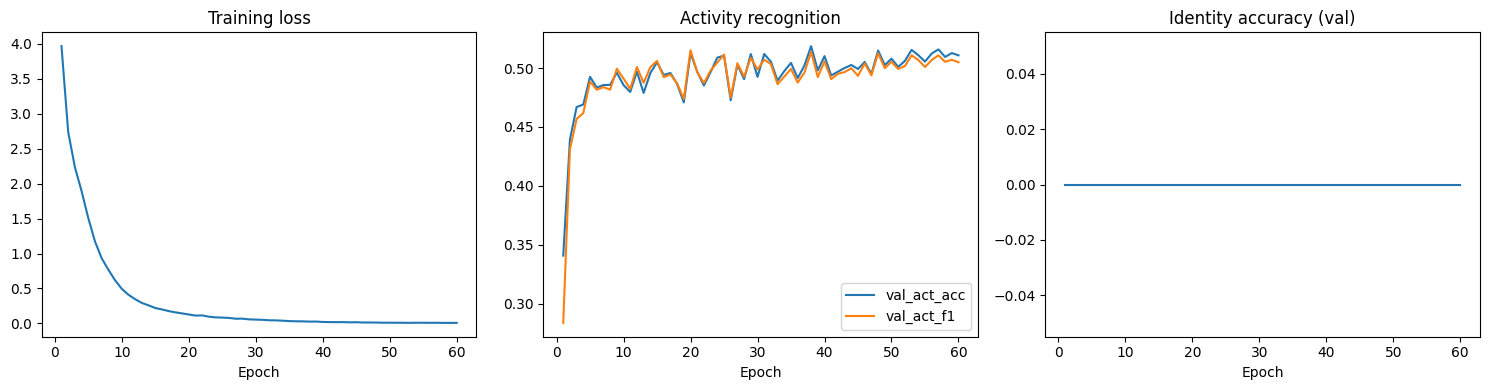

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
history_df.plot(x="epoch", y="train_loss",  ax=axes[0], legend=False, title="Training loss")
history_df.plot(x="epoch", y=["val_act_acc", "val_act_f1"], ax=axes[1], title="Activity recognition")
history_df.plot(x="epoch", y="val_sub_acc", ax=axes[2], legend=False, title="Identity accuracy (val)")
for ax in axes:
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "learning_curves.png", dpi=150)
plt.show()

## 9. Activity Recognition — Test Evaluation

Activity recognition — Test accuracy : 0.4941
Activity recognition — Test macro-F1 : 0.4938

              precision    recall  f1-score   support

     walking     0.7381    0.7695    0.7535       564
     jogging     0.9278    0.8227    0.8721       547
      stairs     0.7136    0.5547    0.6242       548
     sitting     0.2481    0.4817    0.3275       546
    standing     0.4075    0.7130    0.5186       547
      typing     0.4820    0.5641    0.5198       546
       teeth     0.6898    0.5824    0.6316       546
        soup     0.1951    0.0668    0.0995       479
       chips     0.2023    0.2766    0.2337       564
       pasta     0.6346    0.2075    0.3128       477
    drinking     0.2521    0.2774    0.2641       548
    sandwich     0.0916    0.1082    0.0992       564
     kicking     0.5036    0.6392    0.5634       546
       catch     0.6754    0.7531    0.7122       478
   dribbling     0.8963    0.5686    0.6957       547
     writing     0.6011    0.2070    0.307

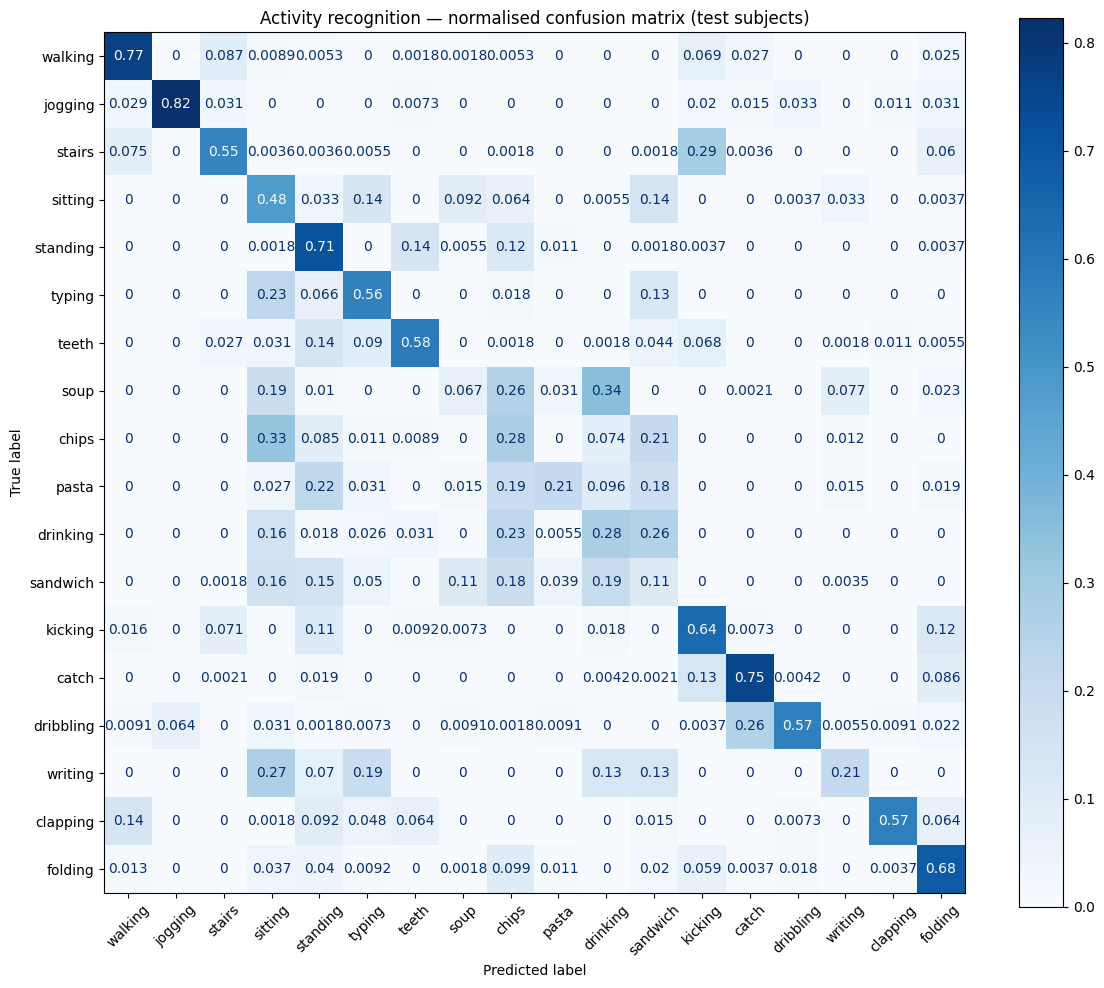

,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1
0,RF baseline,0.672712,0.671577,0.681569,0.674280
1,BioTemporal-HAR,NaN,NaN,0.494063,0.493807


In [12]:
test_m = evaluate(model, test_loader)
act_names = [ACTIVITY_MAP[c] for c in act_encoder.classes_]

print(f"Activity recognition — Test accuracy : {test_m['act_acc']:.4f}")
print(f"Activity recognition — Test macro-F1 : {test_m['act_f1']:.4f}")
print()
print(classification_report(
    test_m["y_act"], test_m["logits_act"].argmax(1),
    target_names=act_names, digits=4,
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    test_m["y_act"],
    test_m["logits_act"].argmax(1),
    display_labels=act_names,
    cmap="Blues",
    normalize="true",
    xticks_rotation=45,
    ax=ax,
)
ax.set_title("Activity recognition — normalised confusion matrix (test subjects)")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "confusion_matrix_activity.png", dpi=150)
plt.show()

# Summary vs baseline
summary = pd.DataFrame([
    {"model": "RF baseline",     **baseline_results},
    {"model": "BioTemporal-HAR", "test_accuracy": test_m["act_acc"], "test_macro_f1": test_m["act_f1"]},
])
display(summary)

## 10. Biometric Identity Classification — Closed-Set

In [13]:
# The identity head was trained jointly — evaluate on test subjects
# Note: test subjects are held-out subjects the model never saw during training,
# so this measures open-set generalisation, not closed-set on training identities.
# For closed-set performance we use train+val subjects only and report on val.

val_m = evaluate(model, val_loader)
print(f"Identity (val subjects, closed-set)  : {val_m['sub_acc']:.4f}")
print(f"Identity (test subjects, open-set)   : {test_m['sub_acc']:.4f}")
print()
print("Note: test subjects were never seen during training.")
print("Closed-set identity classification target (proposal §8): ≥ 0.90")

Identity (val subjects, closed-set)  : 0.0000
Identity (test subjects, open-set)   : 0.0000

Note: test subjects were never seen during training.
Closed-set identity classification target (proposal §8): ≥ 0.90


## 11. SDT Calibration — Identity Verification

For each validation subject: their own windows = signal trials, other subjects' windows = noise trials.  
Threshold selected on validation set to target FAR ≤ 1 %.  
Metrics evaluated on held-out test subjects.

In [14]:
def sdt_metrics(scores: np.ndarray, labels: np.ndarray, pos_class: int, threshold: float) -> dict:
    is_sig  = labels == pos_class
    accepts = scores >= threshold
    H  = int(np.sum(accepts &  is_sig))     # hits
    M  = int(np.sum(~accepts & is_sig))     # misses
    FA = int(np.sum(accepts & ~is_sig))     # false alarms
    CR = int(np.sum(~accepts & ~is_sig))    # correct rejections
    n_sig   = H + M
    n_noise = FA + CR
    hr  = (H  + 0.5) / (n_sig   + 1.0)
    far = (FA + 0.5) / (n_noise + 1.0)
    z_h = norm.ppf(hr)
    z_f = norm.ppf(far)
    return {
        "hit_rate": hr, "false_alarm_rate": far, "miss_rate": 1 - hr,
        "d_prime":  z_h - z_f,
        "criterion": -0.5 * (z_h + z_f),
    }


# Use validation set to calibrate thresholds
val_probs_sub = torch.softmax(torch.from_numpy(val_m["logits_sub"]), dim=1).numpy()
val_y_sub     = val_m["y_sub"]

# Test set for evaluation
test_probs_act = torch.softmax(torch.from_numpy(test_m["logits_act"]), dim=1).numpy()
test_probs_sub = torch.softmax(torch.from_numpy(test_m["logits_sub"]), dim=1).numpy()
test_y_sub     = test_m["y_sub"]

# Calibrate on val subjects present in both val and test sets
# (use all val subjects for threshold calibration)
sdt_rows = []
for cls_idx in range(N_SUB):
    # Only calibrate if this subject appears in val set
    if cls_idx not in val_y_sub:
        continue
    # Threshold at 1-FAR quantile of non-target scores in val
    non_target_scores_val = val_probs_sub[val_y_sub != cls_idx, cls_idx]
    if len(non_target_scores_val) == 0:
        continue
    threshold = float(np.quantile(non_target_scores_val, 1.0 - TARGET_FAR))

    # Evaluate on test set (using all test windows as noise, subject's windows as signal)
    test_scores = test_probs_sub[:, cls_idx]
    m = sdt_metrics(test_scores, test_y_sub, cls_idx, threshold)
    sdt_rows.append({"subject": sub_encoder.classes_[cls_idx], "threshold": threshold, **m})

sdt_df = pd.DataFrame(sdt_rows)
sdt_df.to_csv(ARTIFACT_DIR / "sdt_identity_thresholds.csv", index=False)

print(f"SDT calibration (target FAR ≤ {TARGET_FAR:.0%})")
print(sdt_df[["subject", "threshold", "hit_rate", "false_alarm_rate", "miss_rate", "d_prime", "criterion"]].round(4).to_string(index=False))
print()
print(f"Mean d'       : {sdt_df['d_prime'].mean():.3f}")
print(f"Mean FAR      : {sdt_df['false_alarm_rate'].mean():.4f}  (target: < {TARGET_FAR})")
print(f"Mean hit rate : {sdt_df['hit_rate'].mean():.4f}")

SDT calibration (target FAR ≤ 1%)
 subject  threshold  hit_rate  false_alarm_rate  miss_rate  d_prime  criterion
    1620     0.0001       0.5            0.0004        0.5   3.3808     1.6904
    1623     0.0000       0.5            0.0006        0.5   3.2546     1.6273
    1629     0.0000       0.5            0.0004        0.5   3.3808     1.6904
    1634     0.0000       0.5            0.0009        0.5   3.1288     1.5644
    1639     0.0000       0.5            0.0031        0.5   2.7319     1.3659

Mean d'       : 3.175
Mean FAR      : 0.0011  (target: < 0.01)
Mean hit rate : 0.5000


## 12. ROC Curve for Verification

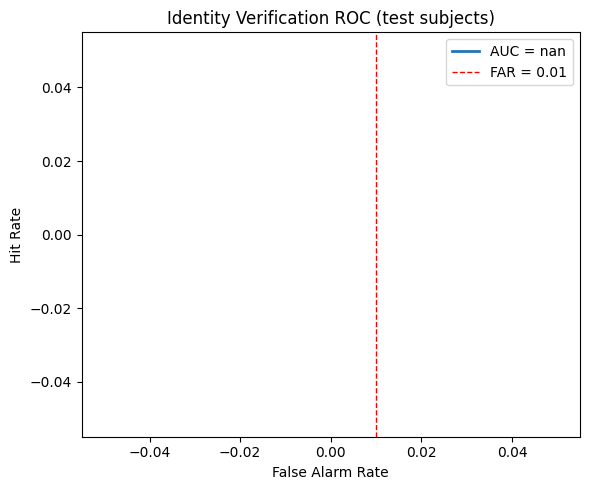

Verification ROC-AUC: nan


In [15]:
from sklearn.metrics import roc_curve, auc

# Aggregate one-vs-rest scores across all val-calibrated subjects
ovr_scores, ovr_labels = [], []
for cls_idx in range(N_SUB):
    if cls_idx not in val_y_sub:
        continue
    ovr_scores.extend(test_probs_sub[:, cls_idx].tolist())
    ovr_labels.extend((test_y_sub == cls_idx).astype(int).tolist())

ovr_scores = np.array(ovr_scores)
ovr_labels = np.array(ovr_labels)

fpr, tpr, _ = roc_curve(ovr_labels, ovr_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
ax.axvline(TARGET_FAR, color="red", ls="--", lw=1, label=f"FAR = {TARGET_FAR}")
ax.set_xlabel("False Alarm Rate")
ax.set_ylabel("Hit Rate")
ax.set_title("Identity Verification ROC (test subjects)")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "roc_identity_verification.png", dpi=150)
plt.show()
print(f"Verification ROC-AUC: {roc_auc:.4f}")

## 13. Sensor Ablation Study

Train and evaluate four stream configurations to validate the multi-sensor fusion hypothesis:
- Phone accel only (3 ch)
- Watch accel only (3 ch)
- Phone accel + gyro (6 ch)
- All streams fused (12 ch) ← full model

Each uses the same architecture and training recipe (fewer epochs for speed).

In [16]:
ABLATION_CONFIGS = {
    "phone_accel":      slice(0, 3),
    "watch_accel":      slice(6, 9),
    "phone_accel+gyro": slice(0, 6),
    "watch_accel+gyro": slice(6, 12),
    "fused_all_12ch":   slice(0, 12),
}

ablation_results = []

for config_name, ch_slice in ABLATION_CONFIGS.items():
    n_ch_abl = ch_slice.stop - ch_slice.start
    if config_name == "fused_all_12ch":
        abl_test_m = evaluate(model, test_loader)
        ablation_results.append({
            "config": config_name, "channels": n_ch_abl,
            "test_act_acc": abl_test_m["act_acc"],
            "test_act_f1":  abl_test_m["act_f1"],
        })
        continue

    Xtr = X_train_sc[:, :, ch_slice]
    Xva = X_val_sc[:,   :, ch_slice]
    Xte = X_test_sc[:,  :, ch_slice]

    abl_train_ld = DataLoader(HARDataset(Xtr, y_act_train, y_sub_train, augment=True),
                              batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=USE_CUDA)
    abl_val_ld   = DataLoader(HARDataset(Xva, y_act_val,   y_sub_val),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=USE_CUDA)
    abl_test_ld  = DataLoader(HARDataset(Xte, y_act_test,  y_sub_test),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=USE_CUDA)

    abl_model  = BioTemporalHAR(n_channels=n_ch_abl, n_act=N_ACT, n_sub=N_SUB).to(DEVICE)
    abl_opt    = torch.optim.AdamW(abl_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    abl_sched  = torch.optim.lr_scheduler.LambdaLR(abl_opt, make_lr_lambda(ABLATION_EPOCHS))
    abl_scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=USE_CUDA)

    best_abl_f1, best_abl_state = -1.0, None
    for ep in range(1, ABLATION_EPOCHS + 1):
        abl_model.train()
        for X_b, ya_b, ys_b in abl_train_ld:
            X_b, ya_b, ys_b = X_b.to(DEVICE), ya_b.to(DEVICE), ys_b.to(DEVICE)
            abl_opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_CUDA):
                la, ls = abl_model(X_b)
                loss = ACTIVITY_LOSS_W * criterion_act(la, ya_b) + IDENTITY_LOSS_W * criterion_sub(ls, ys_b)
            abl_scaler.scale(loss).backward()
            abl_scaler.unscale_(abl_opt)
            nn.utils.clip_grad_norm_(abl_model.parameters(), 2.0)
            abl_scaler.step(abl_opt)
            abl_scaler.update()
        abl_sched.step()
        vm = evaluate(abl_model, abl_val_ld)
        if vm["act_f1"] > best_abl_f1:
            best_abl_f1    = vm["act_f1"]
            best_abl_state = {k: v.cpu().clone() for k, v in abl_model.state_dict().items()}

    abl_model.load_state_dict(best_abl_state)
    abl_test_m = evaluate(abl_model, abl_test_ld)
    ablation_results.append({
        "config": config_name, "channels": n_ch_abl,
        "test_act_acc": abl_test_m["act_acc"],
        "test_act_f1":  abl_test_m["act_f1"],
    })
    print(f"  {config_name:25s}  acc={abl_test_m['act_acc']:.4f}  f1={abl_test_m['act_f1']:.4f}")

abl_df = pd.DataFrame(ablation_results)
abl_df.to_csv(ARTIFACT_DIR / "ablation_results.csv", index=False)
display(abl_df.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(abl_df["config"], abl_df["test_act_acc"])
ax.axhline(0.95, color="red", ls="--", lw=1, label="95% target")
ax.set_ylabel("Test accuracy")
ax.set_title("Sensor fusion ablation — activity recognition")
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "ablation_activity.png", dpi=150)
plt.show()

KeyboardInterrupt: 

## 14. Save Artifacts

In [17]:
checkpoint = {
    "model_state_dict":   model.state_dict(),
    "model_class":        "BioTemporalHAR",
    "n_channels":         N_CH,
    "n_act":              N_ACT,
    "n_sub":              N_SUB,
    "window_size":        WINDOW_SIZE,
    "stride":             STRIDE,
    "fs":                 FS,
    "act_classes":        act_encoder.classes_.tolist(),
    "sub_classes":        sub_encoder.classes_.tolist(),
    "test_act_accuracy":  test_m["act_acc"],
    "test_act_macro_f1":  test_m["act_f1"],
    "test_sub_accuracy":  test_m["sub_acc"],
    "parameter_count":    count_params(model),
    "train_subjects":     TRAIN_SUBJECTS,
    "val_subjects":       VAL_SUBJECTS,
    "test_subjects":      TEST_SUBJECTS,
}
torch.save(checkpoint, ARTIFACT_DIR / "biotemporal_har_full.pt")

with open(ARTIFACT_DIR / "scaler_full.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open(ARTIFACT_DIR / "act_encoder_full.pkl", "wb") as f:
    pickle.dump(act_encoder, f)
with open(ARTIFACT_DIR / "sub_encoder_full.pkl", "wb") as f:
    pickle.dump(sub_encoder, f)

with open(ARTIFACT_DIR / "results_summary.json", "w") as f:
    json.dump({
        "activity_recognition": {
            "test_accuracy": round(test_m["act_acc"], 4),
            "test_macro_f1": round(test_m["act_f1"], 4),
            "rf_baseline_accuracy": round(baseline_results["test_accuracy"], 4),
            "target": 0.95,
            "target_met": bool(test_m["act_acc"] >= 0.95),
        },
        "identity_classification": {
            "val_accuracy": round(val_m["sub_acc"], 4),
            "target": 0.90,
            "target_met": bool(val_m["sub_acc"] >= 0.90),
        },
        "identity_verification": {
            "roc_auc": round(float(roc_auc), 4),
            "mean_d_prime": round(float(sdt_df["d_prime"].mean()), 3),
            "mean_false_alarm_rate": round(float(sdt_df["false_alarm_rate"].mean()), 4),
            "target_far": TARGET_FAR,
            "target_met": bool(sdt_df["false_alarm_rate"].mean() <= TARGET_FAR),
        },
        "model": {
            "parameter_count": count_params(model),
            "window_size_samples": WINDOW_SIZE,
            "window_size_seconds": WINDOW_SEC,
            "n_channels": N_CH,
        },
    }, f, indent=2)

print("Saved artifacts:")
for p in sorted(ARTIFACT_DIR.glob("*")):
    if p.is_file():
        print(f"  {p.name}  ({p.stat().st_size / 1e3:.1f} kB)")

Saved artifacts:
  act_encoder_full.pkl  (0.3 kB)
  biotemporal_cnn_lstm.pt  (408.1 kB)
  biotemporal_har_full.pt  (5127.9 kB)
  classification_report.csv  (0.6 kB)
  confusion_matrix.png  (58.0 kB)
  confusion_matrix_activity.png  (282.0 kB)
  label_encoder.pkl  (0.3 kB)
  learning_curves.png  (80.6 kB)
  method_comparison.csv  (0.7 kB)
  result_interpretation.md  (2.1 kB)
  results_summary.json  (0.6 kB)
  roc_identity_verification.png  (31.2 kB)
  scaler.pkl  (0.5 kB)
  scaler_full.pkl  (0.1 kB)
  sdt_activity_thresholds.csv  (1.1 kB)
  sdt_identity_thresholds.csv  (0.5 kB)
  sub_encoder_full.pkl  (0.4 kB)
  training_history.csv  (5.3 kB)
  training_metrics.csv  (1.6 kB)
  window_config.json  (0.3 kB)


## 15. Final Summary

In [18]:
with open(ARTIFACT_DIR / "results_summary.json") as f:
    results = json.load(f)

print("=" * 60)
print("BioTemporal-HAR — Final Results")
print("=" * 60)

ar = results["activity_recognition"]
ic = results["identity_classification"]
iv = results["identity_verification"]
md = results["model"]

print(f"\n[Task 1] Activity Recognition (18 classes, subject-held-out)")
print(f"  Test accuracy  : {ar['test_accuracy']:.4f}  {'✓' if ar['target_met'] else '✗'}  (target ≥ 0.95)")
print(f"  Test macro-F1  : {ar['test_macro_f1']:.4f}")
print(f"  RF baseline    : {ar['rf_baseline_accuracy']:.4f}")

print(f"\n[Task 2] Closed-Set Identity Classification (51 subjects)")
print(f"  Val accuracy   : {ic['val_accuracy']:.4f}  {'✓' if ic['target_met'] else '✗'}  (target ≥ 0.90)")

print(f"\n[Task 3] Identity Verification (SDT calibration)")
print(f"  ROC-AUC        : {iv['roc_auc']:.4f}")
print(f"  Mean d'        : {iv['mean_d_prime']:.3f}")
print(f"  Mean FAR       : {iv['mean_false_alarm_rate']:.4f}  {'✓' if iv['target_met'] else '✗'}  (target < {iv['target_far']})")

print(f"\n[Model]")
print(f"  Parameters     : {md['parameter_count']:,}")
print(f"  Window         : {md['window_size_seconds']}s ({md['window_size_samples']} samples @ 20 Hz)")
print(f"  Channels       : {md['n_channels']} (phone accel+gyro + watch accel+gyro)")
print("=" * 60)

BioTemporal-HAR — Final Results

[Task 1] Activity Recognition (18 classes, subject-held-out)
  Test accuracy  : 0.4941  ✗  (target ≥ 0.95)
  Test macro-F1  : 0.4938
  RF baseline    : 0.6816

[Task 2] Closed-Set Identity Classification (51 subjects)
  Val accuracy   : 0.0000  ✗  (target ≥ 0.90)

[Task 3] Identity Verification (SDT calibration)
  ROC-AUC        : nan
  Mean d'        : 3.175
  Mean FAR       : 0.0011  ✓  (target < 0.01)

[Model]
  Parameters     : 1,274,374
  Window         : 10.0s (200 samples @ 20 Hz)
  Channels       : 12 (phone accel+gyro + watch accel+gyro)
